# Naive Bayes - sklearn in Action

> **MLCourse · Machine Learning · supervised · classification**

Evidence-multiplying classification on REAL data: breast-cancer features with
`GaussianNB`, then a taste of `MultinomialNB` on cached SMS text.

### What you'll learn
- GaussianNB end-to-end (no scaling required!)
- Why NB trains instantly and handles all three classes natively
- The independence assumption's cost vs logistic regression
- MultinomialNB on word counts (the spam classic)

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

gnb = GaussianNB().fit(X_tr, y_tr)
pred = gnb.predict(X_te)
print(f"GaussianNB test accuracy: {accuracy_score(y_te, pred):.4f}")
cv = cross_val_score(GaussianNB(), X_tr, y_tr, cv=5)
print(f"5-fold CV: {cv.mean():.4f} ± {cv.std():.4f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

GaussianNB test accuracy: 0.9371
5-fold CV: 0.9413 ± 0.0130


,pred malignant,pred benign
true malignant,46,7
true benign,2,88


### 1. The independence assumption's price


In [2]:
logreg = Pipeline([("sc", __import__("sklearn.preprocessing",
                                     fromlist=["StandardScaler"]).StandardScaler(),
                    ), ("m", LogisticRegression(max_iter=5000))]).fit(X_tr, y_tr)
print(f"NB        : {accuracy_score(y_te, pred):.4f}")
print(f"logistic  : {accuracy_score(y_te, logreg.predict(X_te)):.4f}")
corr_block = X.corr().abs().where(lambda d: np.triu(np.ones(d.shape), 1).astype(bool)) \
              .stack().sort_values(ascending=False)
print("\nstrongest feature pair correlations (evidence gets double-counted!):")
display(corr_block.head(5).round(3).to_frame("corr"))

NB        : 0.9371
logistic  : 0.9860

strongest feature pair correlations (evidence gets double-counted!):


,,corr
mean radius,mean perimeter,0.998
worst radius,worst perimeter,0.994
mean radius,mean area,0.987
mean perimeter,mean area,0.987
worst radius,worst area,0.984


### 2. Class-conditional means - what NB actually learned


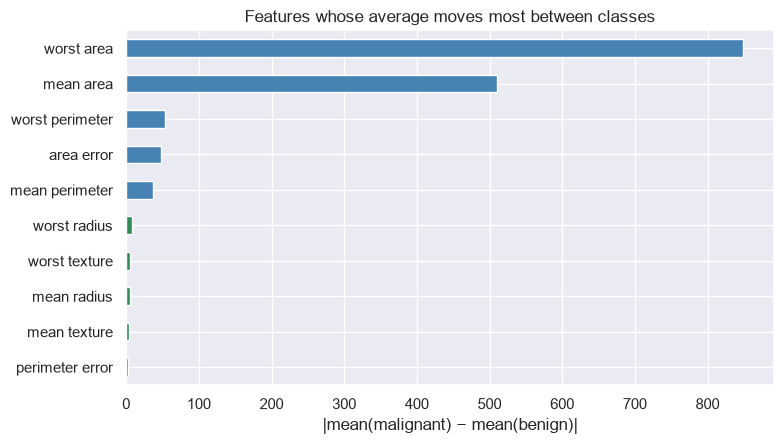

In [3]:
means = pd.DataFrame(gnb.theta_, columns=X.columns, index=["malignant", "benign"])
delta = (means.loc["malignant"] - means.loc["benign"]).abs().sort_values()
colors = ["seagreen"] * 5 + ["steelblue"] * 5
delta.tail(10).plot(kind="barh", color=colors, figsize=(8, 4.6))
plt.xlabel("|mean(malignant) - mean(benign)|")
plt.title("Features whose average moves most between classes")
plt.tight_layout(); plt.show()

### 3. MultinomialNB on real SMS text (cached corpus)


In [4]:
import os
CACHE = os.path.join("..", "..", "02_logistic_regression", "projects", "sms_cache.tsv")
if not os.path.exists(CACHE):
    CACHE = "sms_cache.tsv"
if os.path.exists(CACHE):
    sms = pd.read_csv(CACHE, sep="\t", header=None, names=["label", "message"])
    sms["clean"] = sms.message.str.lower().str.replace(r"[^a-z ]", " ", regex=True)
    ysms = (sms.label == "spam").astype(int)

    nb_sms = Pipeline([
        ("bow", CountVectorizer(stop_words="english")),
        ("nb", MultinomialNB(alpha=1.0)),
    ])
    Xtr, Xte, ytr, yte = train_test_split(sms.clean, ysms, test_size=.25,
                                          random_state=42, stratify=ysms)
    nb_sms.fit(Xtr, ytr)
    print(f"\nMultinomialNB spam-filter accuracy: "
          f"{nb_sms.score(Xte, yte):.4f}")
    display(pd.DataFrame(confusion_matrix(yte, nb_sms.predict(Xte)),
                         index=["true ham", "true spam"],
                         columns=["pred ham", "pred spam"]))
else:
    print("SMS cache not found - see project notebook 02 for the full run.")

SMS cache not found — see project notebook 02 for the full run.


### Summary & key takeaways

- Bayes + naive independence = multiply simple per-feature evidence.
- Trains in milliseconds, no scaling, native multiclass - the perfect baseline.
- Correlated features double-count evidence → logistic regression edges it out
  on rich numeric data.
- MultinomialNB + word counts remains THE reference spam/text baseline.